# Periodic Voxel Fields for $\Omega_m$ Inference
### CNN3D representation and frozen-result analysis
**Notebook 18 · CAMELS-SIMBA · U1000 · Top1500 · saved-artifact analysis**

This post-finalization notebook asks: **How well does a periodic voxel-field CNN recover $\Omega_m$, how stable is its performance, and what does its result tell us about representation choice compared with set-, graph-, temporal-, and summary-based approaches?** No model is trained, tuned, or run for inference here; all performance analysis reads frozen saved predictions.

## 1 — Scientific question and frozen experiment identity

The final snapshot ($a=1$) of each CAMELS-SIMBA universe is represented as a $32^3$ periodic, cell-centred CIC field from the Top1500 halos. The 25 $h^{-1}$ Mpc box gives voxels of $0.78125\ h^{-1}$ Mpc. Channels are deposited count, $\log_{10}M_{m vir}$, and $V_X,V_Y,V_Z$, with fixed divisors [1, 10, 100, 100, 100]; there is no fitted or per-universe normalisation. Seeds 42, 123, and 2025 use 700/99/201 train/validation/test splits.

In [1]:
from pathlib import Path
import hashlib, json, subprocess, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def repo_root(start=Path.cwd()):
    for p in (start, *start.parents):
        if (p/'.git').exists(): return p
    raise RuntimeError('Repository root not found')
ROOT=repo_root(); print('Repository root:', ROOT)
FREEZE=ROOT/'reports/experiment_registry/u1000_top1500_cnn3d_result_freeze.json'
PROTOCOL=ROOT/'reports/experiment_registry/u1000_top1500_cnn3d_protocol_freeze.json'
IMPLEMENTATION=ROOT/'reports/experiment_registry/u1000_top1500_cnn3d_implementation_freeze.json'
EXPECTED={PROTOCOL:'ce934560d21b7823924f235787dd972cdb72abd8f0ebcf452ddd85db11e5b490', IMPLEMENTATION:'692dc965ae3f3f9fac3f0fb16a16a91cb7d7aabf2ff9762cf7341bc2af63fcc8', FREEZE:'f9bf7a103ad8fda5fa3627745bb46b3677ecd8e7f9adc59d002fd9750478c956'}
def sha(p): return hashlib.sha256(p.read_bytes()).hexdigest()
assert all(sha(p)==v for p,v in EXPECTED.items()), 'Frozen provenance SHA mismatch'
protocol=json.loads(PROTOCOL.read_text()); result=json.loads(FREEZE.read_text())
display(pd.DataFrame({'artifact':[p.relative_to(ROOT).as_posix() for p in EXPECTED], 'sha256':[sha(p) for p in EXPECTED], 'verified':[True]*3}))
assert protocol['dataset']['population']==1000 and protocol['dataset']['top_n']==1500
assert result['actual_parameters']==20017 and result['test_attempt_count']['per_seed']==1
print('Dataset: CAMELS-SIMBA U1000 Top1500; seeds:', protocol['seeds'], '; test status:', result['status'])

Repository root: /home/ml/thesis-camels


,artifact,sha256,verified
0,reports/experiment_registry/u1000_top1500_cnn3...,ce934560d21b7823924f235787dd972cdb72abd8f0ebcf...,True
1,reports/experiment_registry/u1000_top1500_cnn3...,692dc965ae3f3f9fac3f0fb16a16a91cb7d7aabf2ff976...,True
2,reports/experiment_registry/u1000_top1500_cnn3...,f9bf7a103ad8fda5fa3627745bb46b3677ecd8e7f9adc5...,True


Dataset: CAMELS-SIMBA U1000 Top1500; seeds: [42, 123, 2025] ; test status: scientifically_closed


## 2 — Provenance and artifact verification

The result freeze is authoritative for run identity and aggregate reporting; each prediction CSV is independently read below. The assertions intentionally fail if a critical frozen provenance invariant changes.

## 3 — CNN3D representation and architecture

Periodic/circular $3^3$ convolutions avoid a non-physical box edge. The compact network is: **Conv3d 5→8 → ReLU → Conv3d 8→16 → ReLU → deterministic non-overlapping 2×2×2 mean downsampling (stride 2) → Conv3d 16→32 → ReLU → AdaptiveAvgPool3d(1) → Linear 32→32 → ReLU → Dropout(0.2) → Linear 32→16 → ReLU → Dropout(0.2) → Linear 16→1**. The frozen implementation uses reshape+mean rather than `nn.AvgPool3d`; it is mathematically equivalent to non-overlapping average pooling. The frozen parameter count is 20,017.

The frozen voxelization returns fields in **[C, X, Y, Z]** order; the representation plot below uses `field.sum(dim=1)`, i.e. a projection along X, leaving the Y–Z plane.

In [2]:
arch=pd.DataFrame([['Conv3d','5 → 8','3³, circular'],['Conv3d','8 → 16','3³, circular'],['Deterministic mean downsampling','16 → 16','2³, stride 2; reshape+mean'],['Conv3d','16 → 32','3³, circular'],['AdaptiveAvgPool3d','32 → 32','global'],['MLP head','32 → 32 → 16 → 1','ReLU; dropout 0.2']],columns=['stage','channels','detail']); display(arch)

,stage,channels,detail
0,Conv3d,5 → 8,"3³, circular"
1,Conv3d,8 → 16,"3³, circular"
2,Deterministic mean downsampling,16 → 16,"2³, stride 2; reshape+mean"
3,Conv3d,16 → 32,"3³, circular"
4,AdaptiveAvgPool3d,32 → 32,global
5,MLP head,32 → 32 → 16 → 1,ReLU; dropout 0.2


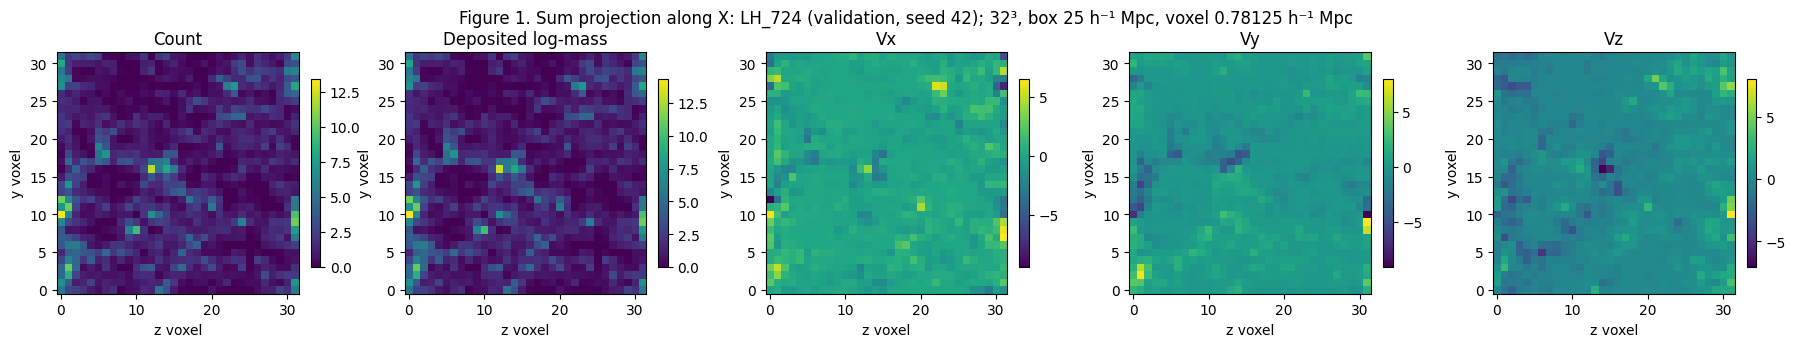

Integrity: valid halos = 1500 ; deposited count = 1499.9998779296875


In [3]:
# Deterministic non-test example: first validation ID in the seed-42 immutable manifest.
import torch
sys.path.insert(0, str(ROOT))
from src.data.halo_voxelization import voxelize_halo_features
manifest=json.loads((ROOT/'configs/splits/u1000_top1500_none_k8_sparse/seed42_train700.json').read_text())
example_id=manifest['val_ids'][0]; data=torch.load(ROOT/protocol['dataset']['path'],map_location='cpu',weights_only=False)
entry=data[example_id]; features=entry['Nodes_list'][-1]; mask=entry['mask_list'][-1].reshape(-1).bool()
field=voxelize_halo_features(features, mask)
assert int(mask.sum())==1500 and np.isclose(float(field[0].sum()),1500.0,atol=1e-3)
fig,axs=plt.subplots(1,5,figsize=(18,3.3),constrained_layout=True)
for ax,im,name in zip(axs, field.sum(dim=1).numpy(), ['Count','Deposited log-mass','Vx','Vy','Vz']):
    h=ax.imshow(im,origin='lower',cmap='viridis'); ax.set_title(name); ax.set_xlabel('z voxel'); ax.set_ylabel('y voxel'); fig.colorbar(h,ax=ax,shrink=.75)
fig.suptitle(f'Figure 1. Sum projection along X: {example_id} (validation, seed 42); 32³, box 25 h⁻¹ Mpc, voxel 0.78125 h⁻¹ Mpc')
plt.show()
print('Integrity: valid halos =',int(mask.sum()),'; deposited count =',float(field[0].sum()))

**Question:** What does CNN3D see? **Observation:** CIC conserves the deposited halo count for a deterministic validation universe. **Interpretation:** these projections expose spatial occupancy and marked velocity/mass structure available to the CNN. **Caution:** this is a representation illustration, not an attribution analysis and it is never passed through the model.

## 4 — CNN3D final metrics

Saved train, validation, and protected-test prediction files are loaded without inference. Test IDs, finiteness, uniqueness, row counts, and frozen metrics are checked.

In [4]:
rows=[]; preds={}; pred_parts={}; manifests={}; integrity=[]; seeds=[42,123,2025]
for run in result['per_seed']:
    seed=run['seed']; base=ROOT/run['run_directory']/'predictions'; manifests[seed]=json.loads((ROOT/'configs/splits/u1000_top1500_none_k8_sparse'/f'seed{seed}_train700.json').read_text())
    parts={s:pd.read_csv(base/f'{s}_predictions.csv').rename(columns={'true_omega_m':'y_true','pred_omega_m':'y_pred'}) for s in ['train','val','test']}
    pred_parts[seed]=parts
    id_sets=[]
    for split,n,key,label in [('train',700,'train_ids','train'),('val',99,'val_ids','validation'),('test',201,'test_ids','test')]:
        d=parts[split]; assert len(d)==n and d['universe_id'].is_unique and d['universe_id'].tolist()==manifests[seed][key] and np.isfinite(d[['y_true','y_pred']].to_numpy()).all()
        id_sets.append(set(d['universe_id'])); integrity.append({'Seed':f'Seed {seed}','Partition':label,'Rows':len(d),'Unique IDs':True,'Manifest order exact':True,'Finite target/prediction':True,'PASS':'PASS'})
    assert not (id_sets[0]&id_sets[1]) and not (id_sets[0]&id_sets[2]) and not (id_sets[1]&id_sets[2])
    d=parts['test']; preds[seed]=d
    calc={'mae':mean_absolute_error(d.y_true,d.y_pred),'mse':mean_squared_error(d.y_true,d.y_pred),'rmse':mean_squared_error(d.y_true,d.y_pred)**.5,'r2':r2_score(d.y_true,d.y_pred)}
    for k,v in calc.items(): assert np.isclose(v,run['test_metrics'][k])
    rows.append({'Seed':seed,'Best epoch':run['best_epoch'],'Val MAE':run['validation_metrics']['mae'],'Val RMSE':run['validation_metrics']['rmse'],'Val R²':run['validation_metrics']['r2'],'Test MAE':calc['mae'],'Test RMSE':calc['rmse'],'Test R²':calc['r2']})
metrics=pd.DataFrame(rows); display(metrics.style.format(precision=5))
display(pd.DataFrame(integrity).style.hide(axis='index')); print('PASS — saved IDs exactly match immutable manifests; partitions are disjoint.')

,Seed,Best epoch,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²
0,42,154,0.01862,0.02200,0.96172,0.01770,0.02249,0.96548
1,123,138,0.01820,0.02240,0.96297,0.02036,0.02463,0.95341
2,2025,101,0.01903,0.02381,0.95962,0.02310,0.02934,0.94059


Seed,Partition,Rows,Unique IDs,Manifest order exact,Finite target/prediction,PASS
Seed 42,train,700,True,True,True,PASS
Seed 42,validation,99,True,True,True,PASS
Seed 42,test,201,True,True,True,PASS
Seed 123,train,700,True,True,True,PASS
Seed 123,validation,99,True,True,True,PASS
Seed 123,test,201,True,True,True,PASS
Seed 2025,train,700,True,True,True,PASS
Seed 2025,validation,99,True,True,True,PASS
Seed 2025,test,201,True,True,True,PASS


PASS — saved IDs exactly match immutable manifests; partitions are disjoint.


## 5 — True versus predicted $\Omega_m$

**Question:** Does CNN3D track the target range rather than collapse to a mean?

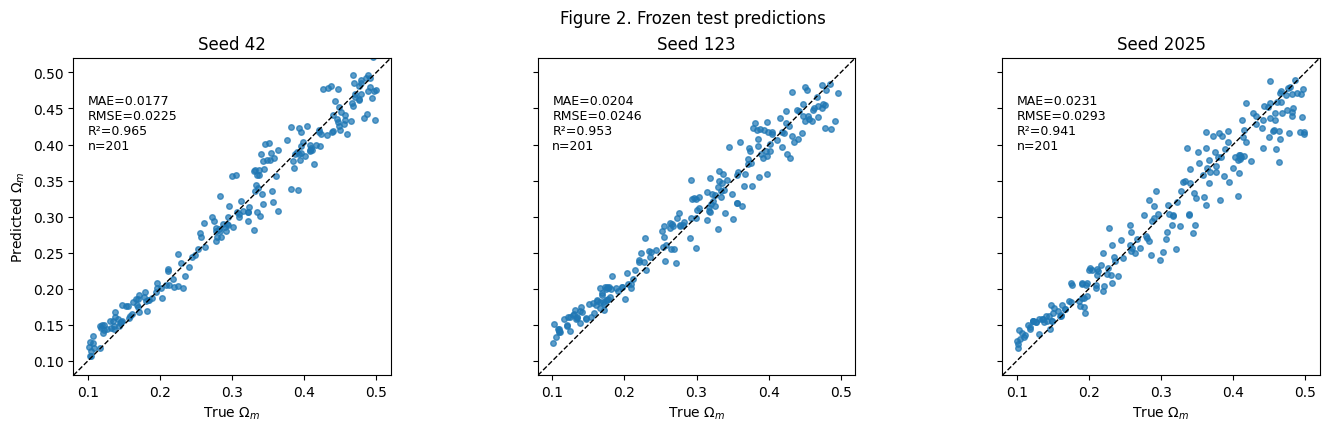

In [5]:
fig,axs=plt.subplots(1,3,figsize=(14,4.2),sharex=True,sharey=True,constrained_layout=True); lim=(.08,.52)
for ax,seed in zip(axs,seeds):
 d=preds[seed]; ax.scatter(d.y_true,d.y_pred,s=16,alpha=.72); ax.plot(lim,lim,'k--',lw=1); r=metrics.query('Seed==@seed').iloc[0]
 ax.set(title=f'Seed {seed}',xlim=lim,ylim=lim,aspect='equal',xlabel='True $\Omega_m$'); ax.text(.10,.47,f"MAE={r['Test MAE']:.4f}\nRMSE={r['Test RMSE']:.4f}\nR²={r['Test R²']:.3f}\nn=201",va='top',fontsize=9)
axs[0].set_ylabel('Predicted $\Omega_m$'); fig.suptitle('Figure 2. Frozen test predictions'); plt.show()

**Observation:** the point clouds follow the identity line across the tested range, rather than forming a near-horizontal band. **Interpretation:** the frozen CNN3D predictions track substantial target variation. **Caution:** deviations from identity, especially near range extremes, remain scientifically relevant.

## 6 — Prediction compression / calibration diagnostics

,Seed,slope,intercept,sd(pred),sd(true),spread ratio
0,42,0.9375,0.0218,0.1157,0.1214,0.9535
1,123,0.8895,0.0395,0.1037,0.1144,0.9066
2,2025,0.8752,0.0348,0.1085,0.1207,0.8994


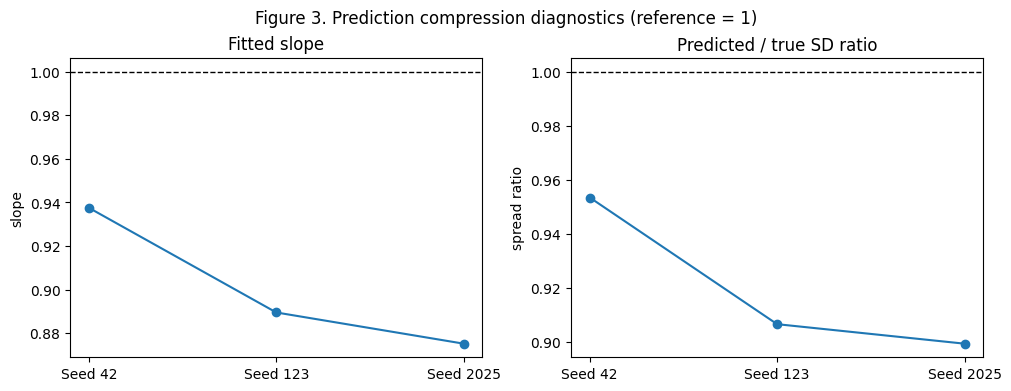

In [6]:
cal=[]
for seed,d in preds.items():
 slope,intercept=np.polyfit(d.y_true,d.y_pred,1); cal.append([seed,slope,intercept,d.y_pred.std(ddof=1),d.y_true.std(ddof=1),d.y_pred.std(ddof=1)/d.y_true.std(ddof=1)])
cal=pd.DataFrame(cal,columns=['Seed','slope','intercept','sd(pred)','sd(true)','spread ratio']); display(cal.style.format(precision=4))
pos=np.arange(len(seeds)); fig,axs=plt.subplots(1,2,figsize=(10,3.8),constrained_layout=True)
for ax,col,title in zip(axs,['slope','spread ratio'],['Fitted slope','Predicted / true SD ratio']):
 ax.plot(pos,cal[col],marker='o'); ax.axhline(1,color='k',lw=1,ls='--'); ax.set(xticks=pos,xticklabels=[f'Seed {z}' for z in seeds],ylabel=col,title=title)
fig.suptitle('Figure 3. Prediction compression diagnostics (reference = 1)'); plt.show()

**Question:** Is variation compressed towards the mean? **Interpretation:** slopes and spread ratios quantify the visual result descriptively; they are not calibration parameters and are never applied to predictions. **Caution:** no arbitrary threshold is used.

## 7 — Residual analysis

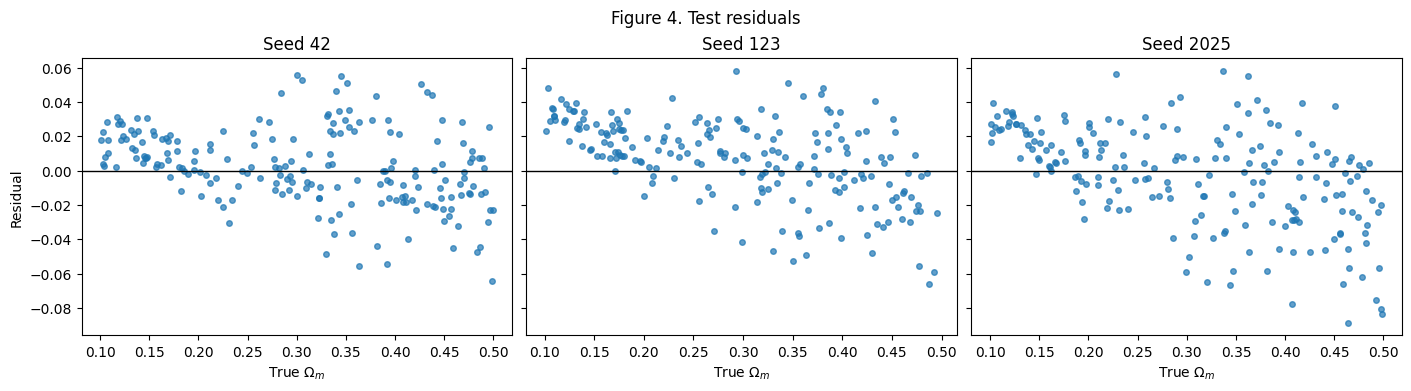

In [7]:
fig,axs=plt.subplots(1,3,figsize=(14,3.8),sharey=True,constrained_layout=True)
for ax,seed in zip(axs,seeds):
 d=preds[seed]; res=d.y_pred-d.y_true; ax.scatter(d.y_true,res,s=16,alpha=.7); ax.axhline(0,color='k',lw=1); ax.set(title=f'Seed {seed}',xlabel='True $\Omega_m$')
axs[0].set_ylabel('Residual'); fig.suptitle('Figure 4. Test residuals'); plt.show()

**Question:** Where do errors occur? **Observation:** residuals permit direct inspection of low/high-target bias and changing spread. **Caution:** with 201 points per seed and three seeds, local patterns are descriptive, not significance tests.

## 8 — Validation-to-test generalization and 9 — Seed stability

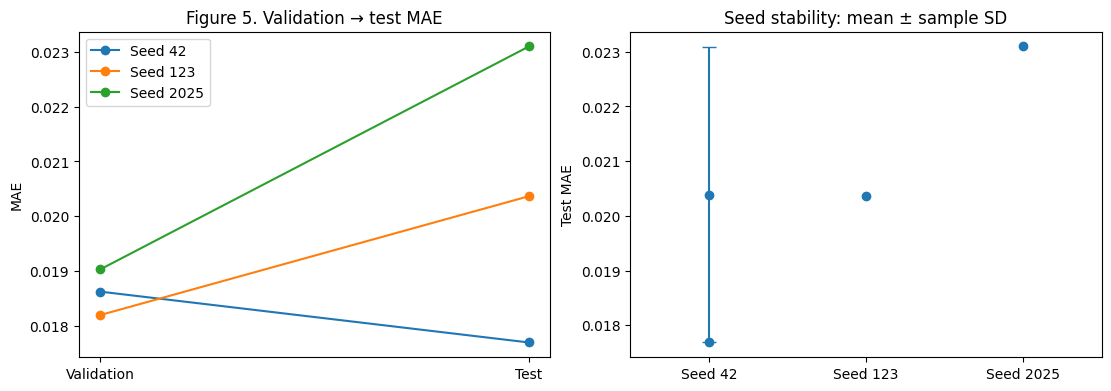

   seed  test minus validation MAE
0    42                  -0.000928
1   123                   0.002168
2  2025                   0.004066
Aggregate: 0.0017688877315573705 +/- 0.0025207186509124866


In [8]:
gaps=np.array([r['test_minus_validation_mae'] for r in result['per_seed']]); fig,axs=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
for r in result['per_seed']: axs[0].plot(['Validation','Test'],[r['validation_metrics']['mae'],r['test_metrics']['mae']],marker='o',label=f"Seed {r['seed']}")
axs[0].set(ylabel='MAE',title='Figure 5. Validation → test MAE'); axs[0].legend()
axs[1].errorbar([0],[metrics['Test MAE'].mean()],yerr=[metrics['Test MAE'].std(ddof=1)],fmt='o',capsize=5); seed_pos=np.arange(len(seeds)); axs[1].scatter(seed_pos,metrics['Test MAE']); axs[1].set(xlim=(-.5,2.5),xticks=seed_pos,xticklabels=[f'Seed {z}' for z in seeds],ylabel='Test MAE',title='Seed stability: mean ± sample SD'); plt.show()
print(pd.DataFrame({'seed':seeds,'test minus validation MAE':gaps})); print('Aggregate:',gaps.mean(),'+/-',gaps.std(ddof=1))

## 10 — Matched static representation comparison and 11 — Paired seed comparison

The comparison changes both representation and architecture; it supports a pipeline comparison, not an architecture-only causal claim.

,Model,MAE,SD,Parameters,Family
0,CNN3D,0.02039,0.00270,20017,Voxel
1,Static GCN,0.03789,0.00094,5281,Static control
2,PNA,0.04484,0.00831,51553,Static control
3,DeepSets,0.04805,0.00099,4161,Static control
4,Set Transformer,0.04977,0.00138,11313,Static control


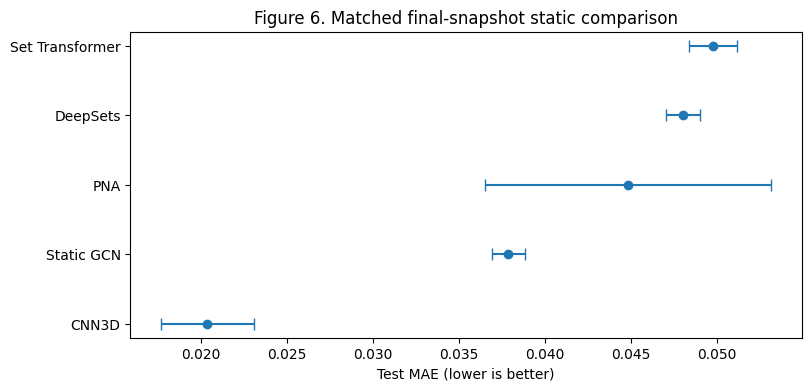

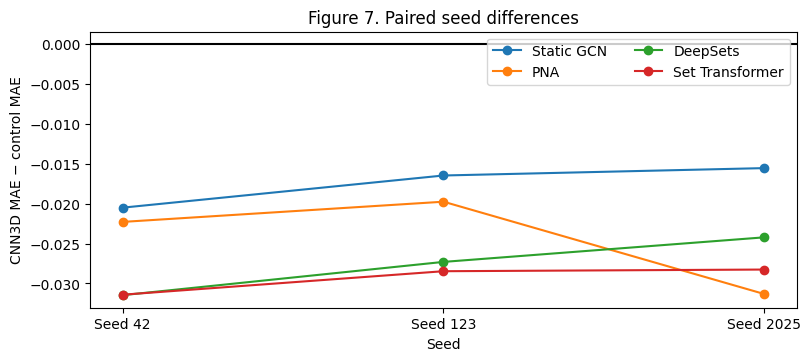

In [9]:
static=['CNN3D','Static GCN','PNA','DeepSets','Set Transformer']; comp=result['comparisons']
model_rows=[{'Model':'CNN3D','MAE':result['aggregates']['test']['mae']['mean'],'SD':result['aggregates']['test']['mae']['sample_sd'],'Parameters':20017,'Family':'Voxel'}]+[{'Model':m,'MAE':comp[m]['test_mae']['mean'],'SD':comp[m]['test_mae']['sample_sd'],'Parameters':comp[m]['parameter_count'],'Family':'Static control'} for m in static[1:]]
static_df=pd.DataFrame(model_rows); display(static_df.style.format({'MAE':'{:.5f}','SD':'{:.5f}'}))
fig,ax=plt.subplots(figsize=(8,3.8),constrained_layout=True); q=static_df.sort_values('MAE'); ax.errorbar(q.MAE,q.Model,xerr=q.SD,fmt='o',capsize=4); ax.set(xlabel='Test MAE (lower is better)',title='Figure 6. Matched final-snapshot static comparison'); plt.show()
fig,ax=plt.subplots(figsize=(8,3.5),constrained_layout=True)
for m in static[1:]: ax.plot(np.arange(len(seeds)),[x['cnn_minus_control_mae'] for x in comp[m]['per_seed']],marker='o',label=m)
ax.axhline(0,color='k'); ax.set(xlabel='Seed',xticks=np.arange(len(seeds)),xticklabels=[f'Seed {z}' for z in seeds],ylabel='CNN3D MAE − control MAE',title='Figure 7. Paired seed differences'); ax.legend(ncol=2); plt.show()

**Observation:** all paired differences are below zero: CNN3D has lower MAE than every matched control for every seed. **Caution:** $n=3$ supports descriptive consistency only; representation and architecture both changed.

## 12 — Broader thesis model comparison and 13 — Parameter count versus performance

Temporal models receive five snapshots and are broader context, not input-matched controls. Engineered summaries are a distinct representation family.

,Model,Family,MAE,SD,Parameters,Authority
3,Gradient Boosting,Engineered summary,0.00917,0.00051,nan,Notebook 17 finalized availability freeze
2,Random Forest,Engineered summary,0.00938,0.00054,nan,Notebook 17 finalized availability freeze
4,Summary MLP,Engineered summary,0.01144,0.00091,nan,Notebook 17 finalized availability freeze
13,CNN3D,Voxel/grid,0.02039,0.00270,20017.000000,CNN3D result freeze
1,Ridge,Engineered summary,0.02397,0.00048,nan,Notebook 17 finalized availability freeze
11,GCN-GRU,Temporal graph,0.02939,0.00048,nan,Notebook 17 finalized availability freeze
10,EvolveGCN-O,Temporal graph,0.03264,0.00251,nan,Notebook 17 finalized availability freeze
12,GCN Temporal Transformer,Temporal graph,0.03534,0.00309,nan,Notebook 17 finalized availability freeze
7,Static GCN,Static graph,0.03789,0.00094,nan,Notebook 17 finalized availability freeze
8,PNA,Static graph,0.04484,0.00831,nan,Notebook 17 finalized availability freeze


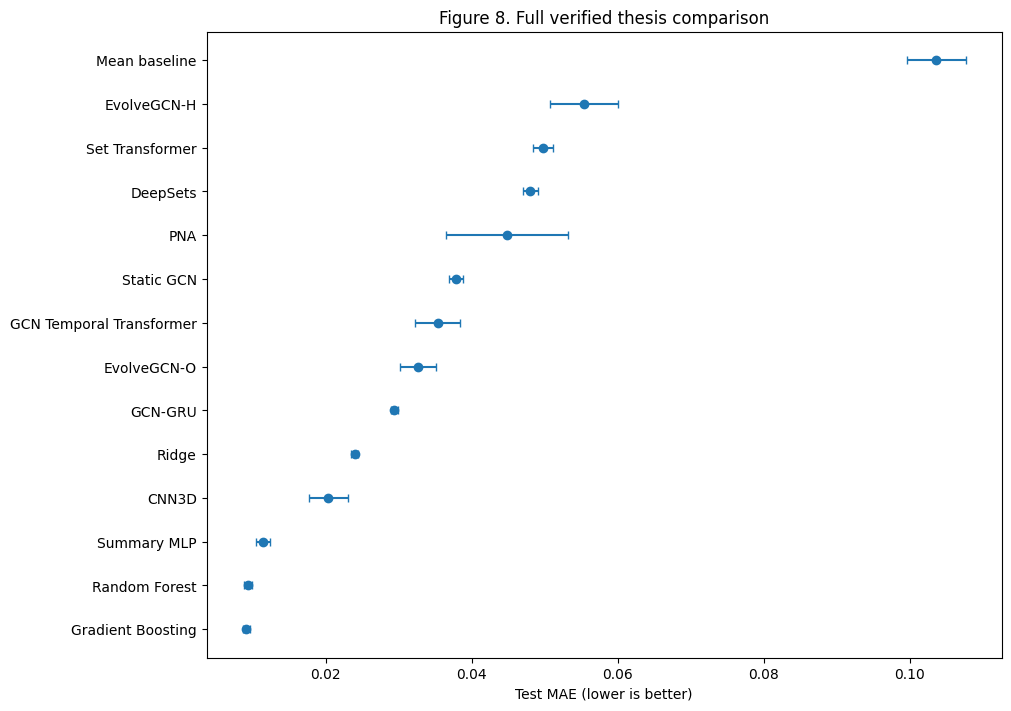

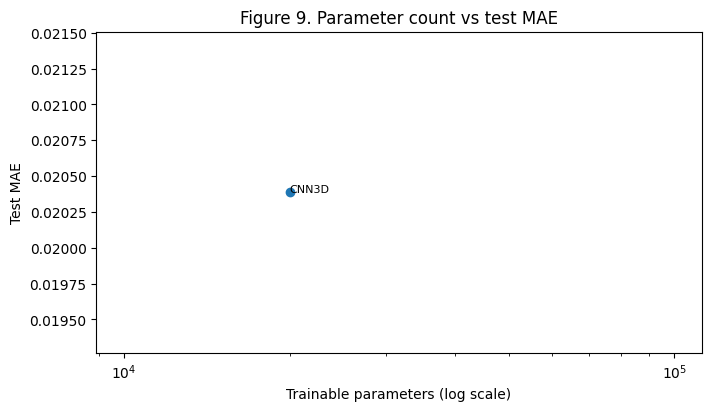

In [10]:
BROAD=ROOT/'reports/experiment_registry/u1000_top1500_set_transformer_final_result_freeze.json'
expected_broad_hash=next(x['sha256'] for x in result['comparison_authorities'] if x['path']==BROAD.relative_to(ROOT).as_posix())
assert sha(BROAD)==expected_broad_hash
broad=json.loads(BROAD.read_text()); assert broad['status']=='finalized' and broad['seeds']==seeds
available={('Mean baseline' if x['model']=='Target mean' else x['model']):x for x in broad['broad_model_availability']}
order=['Mean baseline','Ridge','Random Forest','Gradient Boosting','Summary MLP','DeepSets','Set Transformer','Static GCN','PNA','EvolveGCN-H','EvolveGCN-O','GCN-GRU','GCN Temporal Transformer','CNN3D']
family={'Mean baseline':'Baseline','Ridge':'Engineered summary','Random Forest':'Engineered summary','Gradient Boosting':'Engineered summary','Summary MLP':'Engineered summary','DeepSets':'Raw set','Set Transformer':'Raw set','Static GCN':'Static graph','PNA':'Static graph','EvolveGCN-H':'Temporal graph','EvolveGCN-O':'Temporal graph','GCN-GRU':'Temporal graph','GCN Temporal Transformer':'Temporal graph','CNN3D':'Voxel/grid'}
allrows=[]
for m in order:
 if m=='CNN3D': q=result['aggregates']['test']['mae']; params=20017; authority='CNN3D result freeze'
 else:
  a=available[m]; assert a['available'] and a['final'] and a['safe_to_use'] and a['matched_split_ids']; v=np.array([x['metrics']['test']['mae'] for x in a['runs']]); q={'mean':v.mean(),'sample_sd':v.std(ddof=1)}; params=None; authority='Notebook 17 finalized availability freeze'
 allrows.append({'Model':m,'Family':family[m],'MAE':q['mean'],'SD':q['sample_sd'],'Parameters':params,'Authority':authority})
all_df=pd.DataFrame(allrows).sort_values('MAE'); display(all_df.style.format({'MAE':'{:.5f}','SD':'{:.5f}'}))
for m in comp: assert np.isclose(all_df.set_index('Model').loc[m,'MAE'],comp[m]['test_mae']['mean'])
fig,ax=plt.subplots(figsize=(10,7),constrained_layout=True); ax.errorbar(all_df.MAE,all_df.Model,xerr=all_df.SD,fmt='o',capsize=3); ax.set(xlabel='Test MAE (lower is better)',title='Figure 8. Full verified thesis comparison'); plt.show()
neural=all_df.dropna(subset=['Parameters']); fig,ax=plt.subplots(figsize=(7,4),constrained_layout=True); ax.scatter(neural.Parameters,neural.MAE); [ax.annotate(m,(p,e),fontsize=8) for m,p,e in zip(neural.Model,neural.Parameters,neural.MAE)]; ax.set(xscale='log',xlabel='Trainable parameters (log scale)',ylabel='Test MAE',title='Figure 9. Parameter count vs test MAE'); plt.show()

## 14 — Scientific findings

1. CNN3D tracks $\Omega_m$ across the target range while showing modest compression toward the mean (slopes and spread ratios below 1).
2. The periodic voxel-field + CNN pipeline has lower MAE than the tested matched set/static-graph pipelines in every paired seed.
3. Test MAE is more variable than validation MAE, so the mean must be reported with seed variability.
4. CNN3D is stronger than the verified temporal graph context despite using only one snapshot; this is not an input-matched test.
5. Gradient Boosting and Random Forest engineered summaries remain more accurate than CNN3D.
6. Parameter count alone does not explain the ordering. These results indicate representation choice is a central bottleneck in the tested learned raw-halo models.

## 15 — Limitations and interpretation boundaries

Only three seeds are available. CNN3D changes representation and architecture; static CNN uses one final snapshot whereas temporal models use five; summary models use engineered statistics; parameter count is not compute cost; no significance claim is made from $n=3$. Conclusions apply only to CAMELS-SIMBA U1000 Top1500. Test data are displayed solely after finalization and must not drive any hyperparameter, architecture, representation, seed, or model-selection decision.

## 16 — Reproducibility / notebook audit summary

This notebook verifies the three frozen hashes, loads saved prediction CSVs, asserts exact manifest ID order and partition disjointness, and recomputes metrics and diagnostics, and uses the frozen CIC implementation only to visualize a deterministic validation example. It performs no training, checkpoint loading, test inference, registry mutation, or writes to scientific artifacts.